In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, os, shutil
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from tqdm import tqdm
import warnings; warnings.filterwarnings('ignore')
from sklearn.utils.class_weight import compute_class_weight

GPU          : NVIDIA A100-SXM4-40GB
transformers : 4.44.0
Train: 11,550  Test: 2,888
Tokenizing...
Loading model...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model: cuda:0
Total steps : 1083  Warmup: 108

Epoch  Train Loss   Train Acc   Val Loss    Val Acc
-------------------------------------------------------

Epoch 1/3  LR: 0.00e+00


  Evaluating: 100%|██████████| 91/91 [00:16<00:00,  5.63it/s]


1      0.9806       0.5617      0.7663      0.6406  ← best saved

Epoch 2/3  LR: 2.22e-05


...

2      0.6900       0.6727      0.7347      0.6544  ← best saved

Epoch 3/3  LR: 1.11e-05


  Evaluating: 100%|██████████| 91/91 [00:16<00:00,  5.58it/s]


3      0.5935       0.7032      0.7649      0.6489

Best Val Accuracy: 0.6544


  Evaluating: 100%|██████████| 91/91 [00:16<00:00,  5.59it/s]



  Test Accuracy : 0.6544  (65.44%)
  Macro F1      : 0.6535

                                 precision    recall  f1-score   support

                      Neoplasms     0.7141    0.8167    0.7620       633
      Digestive System Diseases     0.5120    0.8595    0.6417       299
        Nervous System Diseases     0.5838    0.7688    0.6637       385
        Cardiovascular Diseases     0.6767    0.8508    0.7538       610
General Pathological Conditions     0.7758    0.3132    0.4463       961

                       accuracy                         0.6544      2888
                      macro avg     0.6525    0.7218    0.6535      2888
                   weighted avg     0.6884    0.6544    0.6296      2888



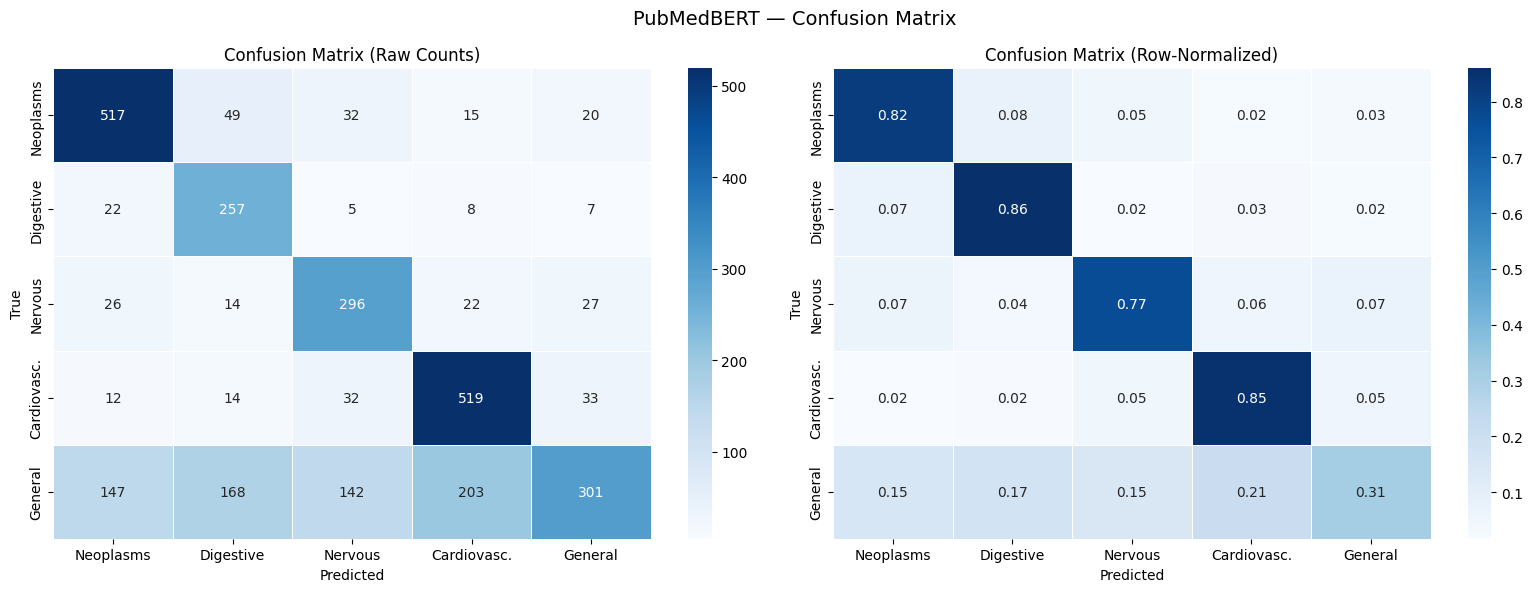

In [ ]:
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

MODEL_NAME = "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext"
MAX_LEN = 512
BATCH_SIZE = 32
EPOCHS = 3
LR = 3e-5
NUM_CLASSES = 5
WARMUP_RATIO = 0.1
LABEL_NAMES = ["Neoplasms",
               "Digestive System Diseases",
               "Nervous System Diseases",
               "Cardiovascular Diseases",
               "General Pathological Conditions"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"transformers: {__import__('transformers').__version__}")

# Load Data
rawdata= load_dataset("TimSchopf/medical_abstracts")
train_df = rawdata["train"].to_pandas()
test_df = rawdata["test"].to_pandas()
text_col, label_col = "medical_abstract", "condition_label"
if text_col not in train_df.columns: text_col = [c for c in train_df.columns if train_df[c].dtype==object][0]
if label_col not in train_df.columns: label_col = [c for c in train_df.columns if train_df[c].dtype!=object][0]
print(f"Train: {len(train_df):,}  Test: {len(test_df):,}")

train_labels = (train_df[label_col].values - 1).astype(int)
test_labels = (test_df[label_col].values - 1).astype(int)

# Tokenize
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
train_enc = tokenizer(list(train_df[text_col].values), padding="max_length", truncation=True, max_length=MAX_LEN)
test_enc  = tokenizer(list(test_df[text_col].values),  padding="max_length", truncation=True, max_length=MAX_LEN)

class MedicalDataset(Dataset):
    def __init__(self, enc, labels):
        self.input_ids = torch.tensor(enc["input_ids"], dtype=torch.long)
        self.attention_mask = torch.tensor(enc["attention_mask"], dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
      return len(self.labels)

    def __getitem__(self, idx):
        return {"input_ids":self.input_ids[idx], "attention_mask":self.attention_mask[idx], "labels":self.labels[idx]}

train_loader = DataLoader(MedicalDataset(train_enc, train_labels), batch_size=BATCH_SIZE, shuffle=True, pin_memory=True, num_workers=0)
test_loader = DataLoader(MedicalDataset(test_enc, test_labels), batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=0)

# Model
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_CLASSES).to(device)
no_decay = ["bias","LayerNorm.weight"]
optimizer = AdamW([
    {"params":[p for n,p in model.named_parameters() if not any(nd in n for nd in no_decay)],"weight_decay":0.01},
    {"params":[p for n,p in model.named_parameters() if any(nd in n for nd in no_decay)],"weight_decay":0.0},
], lr=LR, eps=1e-8)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

class_weights = compute_class_weight("balanced", classes=np.unique(train_labels), y=train_labels)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

print(f"Total steps : {total_steps}  Warmup: {warmup_steps}")

def train_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in tqdm(loader, desc="  Training"):
        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        lbls = batch["labels"].to(device)
        optimizer.zero_grad()
        out = model(input_ids=ids, attention_mask=mask)
        loss = loss_fn(out.logits, lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        correct += (out.logits.argmax(1)==lbls).sum().item()
        total += lbls.size(0)
    return total_loss/len(loader), correct/total

def eval_epoch(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="  Evaluating"):
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            lbls = batch["labels"].to(device)
            out = model(input_ids=ids, attention_mask=mask)
            loss = loss_fn(out.logits, lbls)
            total_loss += loss.item()
            preds = out.logits.argmax(1)
            correct += (preds==lbls).sum().item()
            total += lbls.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())
    return total_loss/len(loader), correct/total, all_preds, all_labels

# Train
if os.path.exists("best_pubmedbert"): shutil.rmtree("best_pubmedbert")
history, best_val_acc = {"train_loss":[],"val_loss":[],"train_acc":[],"val_acc":[]}, 0.0

print(f"\n{'Epoch':<7}{'Train Loss':<13}{'Train Acc':<12}{'Val Loss':<12}{'Val Acc'}")
print("-"*55)

for epoch in range(1, EPOCHS+1):
    current_lr = scheduler.get_last_lr()[0]
    print(f"\nEpoch {epoch}/{EPOCHS}  LR: {current_lr:.2e}")
    tr_loss, tr_acc = train_epoch(model, train_loader)
    vl_loss, vl_acc, _, _ = eval_epoch(model, test_loader)
    history["train_loss"].append(tr_loss); history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc); history["val_acc"].append(vl_acc)
    flag = ""
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        for param in model.parameters():
            param.data = param.data.contiguous()
        model.save_pretrained("best_pubmedbert")
        tokenizer.save_pretrained("best_pubmedbert")
        flag = "  best saved"
    print(f"{epoch:<7}{tr_loss:<13.4f}{tr_acc:<12.4f}{vl_loss:<12.4f}{vl_acc:.4f}{flag}")

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")

# Evaluation
best_model = AutoModelForSequenceClassification.from_pretrained(
    "best_pubmedbert", num_labels=NUM_CLASSES).to(device)
_, _, y_pred, y_true = eval_epoch(best_model, test_loader)
y_pred, y_true = np.array(y_pred), np.array(y_true)

acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")
print(f"\n{'='*50}")
print(f"Test Accuracy: {acc:.4f}  ({acc*100:.2f}%)")
print(f"Macro F1: {macro_f1:.4f}")
print(f"{'='*50}\n")
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES, digits=4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float)/cm.sum(axis=1, keepdims=True)
short = ["Neoplasms","Digestive","Nervous","Cardiovasc.","General"]
fig, axes = plt.subplots(1, 2, figsize=(16,6))
for ax, data, fmt, title in zip(axes,[cm,cm_norm],["d",".2f"],["Raw Counts","Row-Normalized"]):
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=short, yticklabels=short, ax=ax, linewidths=0.5)
    ax.set_title(f"Confusion Matrix ({title})")
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
plt.suptitle("PubMedBERT — Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()